In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import pypsa
from pathlib import Path
import networkx as nx
import numpy as np
import logging

logging.basicConfig(level=logging.WARNING)

In [18]:
import xarray as xr
import dask
import linopy
import pypsa

print("xarray:", xr.__version__)
print("dask:", getattr(dask, "__version__", "no __version__"))
print("linopy:", linopy.__version__)
print("pypsa:", pypsa.__version__)

xarray: 2026.2.0
dask: 2026.3.0
linopy: 0.6.6
pypsa: 1.2.0


In [19]:
YEAR = 2019

BASE_PATH     = "data"
DENMARK_PATH  = f"{BASE_PATH}/Denmark_En_DH"
GERMANY_PATH  = f"{BASE_PATH}/Germany_En_DH"
NORWAY_PATH   = f"{BASE_PATH}/Norway_En_DH"
SWEDEN_PATH   = f"{BASE_PATH}/Sweden_En_DH"
LOAD_PATH     = f"{BASE_PATH}/Load/time_series_60min_singleindex.csv"

In [20]:
def annualize(capex, r, lifetime):
    crf = (r * (1 + r)**lifetime) / ((1 + r)**lifetime - 1)
    return capex * crf

r = 0.07

# Solar
CAPITAL_COST_SOLAR_DE = float(annualize(700_000,   r, lifetime=25))
CAPITAL_COST_SOLAR_DK = float(annualize(772_000,   r, lifetime=25))
CAPITAL_COST_SOLAR_SE = float(annualize(861_000,   r, lifetime=25))

# Wind onshore
CAPITAL_COST_WIND_ON_DE = float(annualize(1_900_000, r, lifetime=25))
CAPITAL_COST_WIND_ON_DK = float(annualize(1_950_000, r, lifetime=25))
CAPITAL_COST_WIND_ON_SE = float(annualize(1_400_000, r, lifetime=25))
CAPITAL_COST_WIND_ON_NO = float(annualize(1_400_000, r, lifetime=25))

# Wind offshore
CAPITAL_COST_WIND_OFF_DE = float(annualize(4_150_000, r, lifetime=25))
CAPITAL_COST_WIND_OFF_DK = float(annualize(2_900_000, r, lifetime=25))

# Gas DK
CAPITAL_COST_GAS_DK = float(annualize(1_300_000, r, lifetime=25))

# Marginal costs DK renewables
MARGINAL_COST_SOLAR_DK   = 0
MARGINAL_COST_WIND_ON_DK = 0
MARGINAL_COST_WIND_OFF_DK = 0
MARGINAL_COST_GAS_DK     = 43.18 / 0.47

In [21]:
snapshots = pd.date_range(
    start=f"{YEAR}-01-01 00:00:00",
    end=f"{YEAR}-12-31 23:00:00",
    freq="h"
)

pv       = pd.read_csv(f"{DENMARK_PATH}/ninja-pv-country-DK-national-merra2.csv", skiprows=3)
wind_on  = pd.read_csv(f"{DENMARK_PATH}/ninja-wind-country-DK-current_onshore-merra2.csv", skiprows=3)
wind_off = pd.read_csv(f"{DENMARK_PATH}/ninja-wind-country-DK-current_offshore-merra2.csv", skiprows=3)
load_df  = pd.read_csv(LOAD_PATH)

pv["time"]       = pd.to_datetime(pv["time"], utc=True)
wind_on["time"]  = pd.to_datetime(wind_on["time"], utc=True)
wind_off["time"] = pd.to_datetime(wind_off["time"], utc=True)
load_df["utc_timestamp"] = pd.to_datetime(load_df["utc_timestamp"], utc=True)

pv       = pv.set_index("time")
wind_on  = wind_on.set_index("time")
wind_off = wind_off.set_index("time")
load_df  = load_df.set_index("utc_timestamp")

pv.index       = pv.index.tz_convert(None)
wind_on.index  = wind_on.index.tz_convert(None)
wind_off.index = wind_off.index.tz_convert(None)
load_df.index  = load_df.index.tz_convert(None)

pv       = pv.loc[f"{YEAR}-01-01":f"{YEAR}-12-31 23:00:00"]
wind_on  = wind_on.loc[f"{YEAR}-01-01":f"{YEAR}-12-31 23:00:00"]
wind_off = wind_off.loc[f"{YEAR}-01-01":f"{YEAR}-12-31 23:00:00"]
load_df  = load_df.loc[f"{YEAR}-01-01":f"{YEAR}-12-31 23:00:00"]

data = pd.DataFrame(index=snapshots)
data["load"]        = load_df["DK_load_actual_entsoe_transparency"]
data["solar_cf"]    = pv["NATIONAL"]
data["wind_on_cf"]  = wind_on["NATIONAL"]
data["wind_off_cf"] = wind_off["NATIONAL"]

data = data.reindex(snapshots).interpolate(method="time").ffill().bfill()

print("DK NaN check:", data.isna().sum().sum())
print(data.head())

DK NaN check: 0
                        load  solar_cf  wind_on_cf  wind_off_cf
2019-01-01 00:00:00  3186.04       0.0    0.805840     0.896970
2019-01-01 01:00:00  3070.07       0.0    0.839171     0.916942
2019-01-01 02:00:00  2966.19       0.0    0.861352     0.927392
2019-01-01 03:00:00  2933.48       0.0    0.882439     0.948853
2019-01-01 04:00:00  2940.64       0.0    0.903024     0.960074


In [22]:
def read_load_energycharts(path, year):
    df = pd.read_csv(path, skiprows=[1])
    df.columns = df.columns.str.strip()
    df = df.rename(columns={df.columns[0]: "time"})
    df["time"] = pd.to_datetime(df["time"], utc=True).dt.tz_convert(None)
    df = df.set_index("time")
    df = df.loc[f"{year}-01-01":f"{year}-12-31 23:00:00"]
    load = df["Load"].astype(float)
    if len(load) > 9000:
        load = load.resample("h").mean()
    load = load[~load.index.duplicated(keep="first")]
    load = load.resample("h").mean().interpolate(method="time")
    return load


def read_country_data(pv_path, wind_on_path, wind_off_path, load_path, year):
    pv_c       = pd.read_csv(pv_path, skiprows=3)
    wind_on_c  = pd.read_csv(wind_on_path, skiprows=3)
    wind_off_c = pd.read_csv(wind_off_path, skiprows=3)

    for df in [pv_c, wind_on_c, wind_off_c]:
        df["time"] = pd.to_datetime(df["time"], utc=True)

    pv_c       = pv_c.set_index("time")
    wind_on_c  = wind_on_c.set_index("time")
    wind_off_c = wind_off_c.set_index("time")

    pv_c.index       = pv_c.index.tz_convert(None)
    wind_on_c.index  = wind_on_c.index.tz_convert(None)
    wind_off_c.index = wind_off_c.index.tz_convert(None)

    pv_c       = pv_c.loc[f"{year}-01-01":f"{year}-12-31 23:00:00"]
    wind_on_c  = wind_on_c.loc[f"{year}-01-01":f"{year}-12-31 23:00:00"]
    wind_off_c = wind_off_c.loc[f"{year}-01-01":f"{year}-12-31 23:00:00"]

    d = pd.DataFrame(index=snapshots)
    d["load"]        = read_load_energycharts(load_path, year).reindex(snapshots)
    d["solar_cf"]    = pv_c["NATIONAL"].astype(float)
    d["wind_on_cf"]  = wind_on_c["NATIONAL"].astype(float)
    d["wind_off_cf"] = wind_off_c["NATIONAL"].astype(float)

    return d.reindex(snapshots).interpolate(method="time").ffill().bfill()


data_de = read_country_data(
    pv_path       = f"{GERMANY_PATH}/ninja-pv-country-DE-national-merra2.csv",
    wind_on_path  = f"{GERMANY_PATH}/ninja-wind-country-DE-current_onshore-merra2.csv",
    wind_off_path = f"{GERMANY_PATH}/ninja-wind-country-DE-current_offshore-merra2.csv",
    load_path     = f"{GERMANY_PATH}/energy-charts_Public_net_electricity_generation_in_Germany_in_2019.csv",
    year=YEAR
)

data_no = read_country_data(
    pv_path       = f"{NORWAY_PATH}/ninja-pv-country-NO-national-merra2.csv",
    wind_on_path  = f"{NORWAY_PATH}/ninja-wind-country-NO-current_onshore-merra2.csv",
    wind_off_path = f"{NORWAY_PATH}/ninja-wind-country-NO-current_offshore-merra2.csv",
    load_path     = f"{NORWAY_PATH}/energy-charts_Public_net_electricity_generation_in_Norway_in_2019.csv",
    year=YEAR
)

data_se = read_country_data(
    pv_path       = f"{SWEDEN_PATH}/ninja-pv-country-SE-national-merra2.csv",
    wind_on_path  = f"{SWEDEN_PATH}/ninja-wind-country-SE-current_onshore-merra2.csv",
    wind_off_path = f"{SWEDEN_PATH}/ninja-wind-country-SE-current_offshore-merra2.csv",
    load_path     = f"{SWEDEN_PATH}/energy-charts_Public_net_electricity_generation_in_Sweden_in_2019.csv",
    year=YEAR
)

print("DE:", data_de.shape, data_de.isna().sum().sum())
print("NO:", data_no.shape, data_no.isna().sum().sum())
print("SE:", data_se.shape, data_se.isna().sum().sum())

DE: (8760, 4) 0
NO: (8760, 4) 0
SE: (8760, 4) 0


In [23]:
def read_hydro(path, hydro_cols, p_nom, year, resample_hourly=False):
    col_names = pd.read_csv(path, nrows=0).columns.tolist()
    df = pd.read_csv(path, skiprows=2, header=None, names=col_names,
                     parse_dates=[0], index_col=0)
    df.index = pd.to_datetime(df.index, utc=True).tz_convert(None)
    df = df.loc[f"{year}-01-01":f"{year}-12-31 23:00:00"]

    hydro_total = df[hydro_cols].sum(axis=1)
    if resample_hourly:
        hydro_total = hydro_total.resample("h").mean()

    d = pd.DataFrame(index=snapshots)
    d["hydro_cf"] = (hydro_total / p_nom).clip(0, 1)
    return d.reindex(snapshots).interpolate(method="time").ffill().bfill()


hydro_de = read_hydro(
    f"{GERMANY_PATH}/energy-charts_Public_net_electricity_generation_in_Germany_in_2019.csv",
    hydro_cols=["Hydro Run-of-River", "Hydro water reservoir", "Hydro pumped storage"],
    p_nom=5900, year=YEAR, resample_hourly=True
)

hydro_no_ror = read_hydro(
    f"{NORWAY_PATH}/energy-charts_Public_net_electricity_generation_in_Norway_in_2019.csv",
    hydro_cols=["Hydro Run of River"],
    p_nom=6300, year=YEAR
)

hydro_no_res = read_hydro(
    f"{NORWAY_PATH}/energy-charts_Public_net_electricity_generation_in_Norway_in_2019.csv",
    hydro_cols=["Hydro water reservoir"],
    p_nom=27530, year=YEAR
)

hydro_se = read_hydro(
    f"{SWEDEN_PATH}/energy-charts_Public_net_electricity_generation_in_Sweden_in_2019.csv",
    hydro_cols=["Hydro water reservoir"],
    p_nom=16320, year=YEAR
)

print("Hydro DE:", hydro_de.shape)
print("Hydro NO RoR:", hydro_no_ror.shape)
print("Hydro NO Res:", hydro_no_res.shape)
print("Hydro SE:", hydro_se.shape)

Hydro DE: (8760, 1)
Hydro NO RoR: (8760, 1)
Hydro NO Res: (8760, 1)
Hydro SE: (8760, 1)


In [24]:
LINE_DK_DE = 2100
LINE_DK_NO = 1700
LINE_DK_SE = 2400
LINE_NO_SE = 3700
LINE_DE_SE = 600

nh = pypsa.Network()
nh.set_snapshots(snapshots)

# --- Buses ---
nh.add("Bus", "Denmark", v_nom=400)
nh.add("Bus", "Germany", v_nom=400)
nh.add("Bus", "Norway",  v_nom=400)
nh.add("Bus", "Sweden",  v_nom=400)

# --- Lines ---
nh.add("Line", "DK-DE", bus0="Denmark", bus1="Germany", x=0.1, s_nom=LINE_DK_DE, s_nom_extendable=False)
nh.add("Line", "DK-NO", bus0="Denmark", bus1="Norway",  x=0.1, s_nom=LINE_DK_NO, s_nom_extendable=False)
nh.add("Line", "DK-SE", bus0="Denmark", bus1="Sweden",  x=0.1, s_nom=LINE_DK_SE, s_nom_extendable=False)
nh.add("Line", "NO-SE", bus0="Norway",  bus1="Sweden",  x=0.1, s_nom=LINE_NO_SE, s_nom_extendable=False)
nh.add("Line", "DE-SE", bus0="Germany", bus1="Sweden",  x=0.1, s_nom=LINE_DE_SE, s_nom_extendable=False)

# --- Denmark (extendable) ---
nh.add("Load", "DK_demand", bus="Denmark", p_set=data["load"].values)
nh.add("Generator", "DK_solar",    bus="Denmark", carrier="solar",
       p_max_pu=data["solar_cf"].values, p_nom_extendable=True,
       capital_cost=CAPITAL_COST_SOLAR_DK, marginal_cost=MARGINAL_COST_SOLAR_DK)
nh.add("Generator", "DK_wind_on",  bus="Denmark", carrier="wind_onshore",
       p_max_pu=data["wind_on_cf"].values, p_nom_extendable=True,
       capital_cost=CAPITAL_COST_WIND_ON_DK, marginal_cost=MARGINAL_COST_WIND_ON_DK)
nh.add("Generator", "DK_wind_off", bus="Denmark", carrier="wind_offshore",
       p_max_pu=data["wind_off_cf"].values, p_nom_extendable=True,
       capital_cost=CAPITAL_COST_WIND_OFF_DK, marginal_cost=MARGINAL_COST_WIND_OFF_DK)

# --- Germany ---
nh.add("Load", "DE_demand", bus="Germany", p_set=data_de["load"].values)
nh.add("Generator", "DE_wind_onshore", bus="Germany", carrier="wind_onshore",
       p_max_pu=data_de["wind_on_cf"].values,
       p_nom=53100, p_nom_min=53100, p_nom_extendable=True,
       marginal_cost=2, capital_cost=CAPITAL_COST_WIND_ON_DE)
nh.add("Generator", "DE_wind_off",     bus="Germany", carrier="wind_offshore",
       p_max_pu=data_de["wind_off_cf"].values,
       p_nom=7700, p_nom_min=7700, p_nom_extendable=True,
       marginal_cost=5, capital_cost=CAPITAL_COST_WIND_OFF_DE)
nh.add("Generator", "DE_solar",        bus="Germany", carrier="solar",
       p_max_pu=data_de["solar_cf"].values,
       p_nom=46200, p_nom_min=46200, p_nom_extendable=True,
       marginal_cost=1, capital_cost=CAPITAL_COST_SOLAR_DE)
nh.add("Generator", "DE_lignite",      bus="Germany", carrier="lignite",
       p_nom=25900, p_nom_extendable=False, marginal_cost=40.6)
nh.add("Generator", "DE_hard_coal",    bus="Germany", carrier="coal",
       p_nom=22670, p_nom_extendable=False, marginal_cost=38.8)
nh.add("Generator", "DE_biomass",      bus="Germany", carrier="biomass",
       p_nom=8270,  p_nom_extendable=False, marginal_cost=57.2)
nh.add("Generator", "DE_hydro",        bus="Germany", carrier="hydro",
       p_nom=4800,  p_nom_extendable=False, marginal_cost=5,
       p_max_pu=hydro_de["hydro_cf"].values)
nh.add("Generator", "DE_nuclear",      bus="Germany", carrier="nuclear",
       p_nom=9500,  p_nom_extendable=False, marginal_cost=8)

# --- Norway ---
nh.add("Load", "NO_demand", bus="Norway", p_set=data_no["load"].values)
nh.add("Generator", "NO_hydro_ror", bus="Norway", carrier="hydro",
       p_nom=6300,  p_nom_extendable=False,
       marginal_cost=3, p_max_pu=hydro_no_ror["hydro_cf"].values)
nh.add("Generator", "NO_hydro_res", bus="Norway", carrier="hydro",
       p_nom=27530, p_nom_extendable=False,
       marginal_cost=2, p_max_pu=hydro_no_res["hydro_cf"].values)
nh.add("Generator", "NO_wind",      bus="Norway", carrier="wind_onshore",
       p_max_pu=data_no["wind_on_cf"].values,
       p_nom=3900, p_nom_min=3900, p_nom_extendable=True,
       marginal_cost=2, capital_cost=CAPITAL_COST_WIND_ON_NO)

# --- Sweden ---
nh.add("Load", "SE_demand", bus="Sweden", p_set=data_se["load"].values)
nh.add("Generator", "SE_hydro",   bus="Sweden", carrier="hydro",
       p_nom=16320, p_nom_extendable=False,
       marginal_cost=3, p_max_pu=hydro_se["hydro_cf"].values)
nh.add("Generator", "SE_nuclear", bus="Sweden", carrier="nuclear",
       p_nom=7710, p_nom_extendable=False, marginal_cost=8)
nh.add("Generator", "SE_wind",    bus="Sweden", carrier="wind_onshore",
       p_max_pu=data_se["wind_on_cf"].values,
       p_nom=9650, p_nom_min=9650, p_nom_extendable=True,
       marginal_cost=2, capital_cost=CAPITAL_COST_WIND_ON_SE)
nh.add("Generator", "SE_solar",   bus="Sweden", carrier="solar",
       p_max_pu=data_se["solar_cf"].values,
       p_nom=1100, p_nom_min=1100, p_nom_extendable=True,
       marginal_cost=1, capital_cost=CAPITAL_COST_SOLAR_SE)

In [25]:
G = nx.Graph()
for line, row in nh.lines.iterrows():
    G.add_edge(row.bus0, row.bus1, name=line)

cycles = nx.cycle_basis(G)
print(f"Número de ciclos independientes: {len(cycles)}")
for i, cycle in enumerate(cycles):
    print(f"  Ciclo {i+1}: {' → '.join(cycle)} → {cycle[0]}")

print(f"Red conectada: {nx.is_connected(G)}")

Número de ciclos independientes: 2
  Ciclo 1: Denmark → Germany → Sweden → Denmark
  Ciclo 2: Denmark → Norway → Sweden → Denmark
Red conectada: True


**PART G**

In [26]:

CAPITAL_COST_ELECTROLYZER = float(annualize(903_906, r, lifetime=40))   # €/MW
CAPITAL_COST_H2_STORAGE   = float(annualize(6_010,  r, lifetime=20))    # €/MWh
CAPITAL_COST_FUEL_CELL = float(annualize(1_591_578, r, lifetime=30))    # €/MW

CAPITAL_COST_CH4_METHA = float(annualize(979_540, r, lifetime=30))   # €/MW
CAPITAL_COST_CH4_STORAGE   = float(annualize(2_974,  r, lifetime=20))    # €/MWh
CAPITAL_COST_CH4_TURBINE = float(annualize(606_401, r, lifetime=25))

CH4_DISTANCES_KM = H2_DISTANCES_KM = {
    ("Denmark", "Germany"): 350,
    ("Denmark", "Norway"):  500,
    ("Denmark", "Sweden"):  300,
    ("Germany", "Sweden"):  800,
    ("Germany", "Norway"):  700,
}


In [ ]:
# --- 0. CONFIGURATION ---
countries = {"DK": "Denmark", "DE": "Germany", "NO": "Norway", "SE": "Sweden"}


# ─── 1. BUSES (H2 and CH4) ──────────────────────────────────────────
for code, name in countries.items():
    nh.add("Bus", f"{name} H2", carrier="H2")
    nh.add("Bus", f"{name} CH4", carrier="CH4")


# ─── 2. H2 SYSTEM ───────────────────────────────────────────────────
for code, name in countries.items():
    # Electrolyzers
    nh.add(
        "Link", f"{code} electrolyzer",
        bus0=name, bus1=f"{name} H2",
        carrier="H2",
        p_nom_extendable=True,
        efficiency=0.58,
        capital_cost=CAPITAL_COST_ELECTROLYZER
    )

    # H2 Storage
    nh.add(
        "Store", f"{code} H2 store",
        bus=f"{name} H2",
        carrier="H2",
        e_nom_extendable=True,
        standing_loss=0.001,
        capital_cost=CAPITAL_COST_H2_STORAGE
    )

    # Fuel Cells
    nh.add(
        "Link", f"{code} fuel cell",
        bus0=f"{name} H2", bus1=name,
        carrier="H2",
        p_nom_extendable=True,
        efficiency=0.4869,
        capital_cost=CAPITAL_COST_FUEL_CELL
    )


# H2 Pipelines
for (a, b), dist in H2_DISTANCES_KM.items():
    nh.add(
        "Link", f"H2 pipeline {a}-{b}",
        bus0=f"{a} H2", bus1=f"{b} H2",
        carrier="H2 pipeline",
        p_nom_extendable=True,
        capital_cost=0
    )
    nh.add(
        "Link", f"H2 pipeline {b}-{a}",
        bus0=f"{b} H2", bus1=f"{a} H2",
        carrier="H2 pipeline",
        p_nom_extendable=True,
        capital_cost=0
    )


# ─── 3. CH4 SYSTEM ──────────────────────────────────────────────────
market_costs = {"DK": 43.18, "DE": 34.78, "NO": 17.26, "SE": 45.35}


gas_market_cap = {
    "DK": None,
    "DE": 30700,
    "NO": 600,
    "SE": 8800
}

for code, name in countries.items():
    cap = gas_market_cap[code]
    is_extendable = cap is None

    # Gas Market
    nh.add(
        "Generator",
        f"{code} CH4 market",
        bus=f"{name} CH4",
        carrier="gas market",
        p_nom=0 if is_extendable else cap,
        p_nom_extendable=is_extendable,
        marginal_cost=market_costs.get(code, 40)
    )

    # Methanation
    nh.add(
        "Link",
        f"{code} methanation",
        bus0=name,
        bus1=f"{name} CH4",
        carrier="CH4",
        p_nom_extendable=True,
        efficiency=0.71,
        capital_cost=CAPITAL_COST_CH4_METHA
    )

    # CH4 Storage
    nh.add(
        "Store",
        f"{code} CH4 store",
        bus=f"{name} CH4",
        carrier="CH4",
        e_nom_extendable=True,
        standing_loss=0.001,
        capital_cost=CAPITAL_COST_CH4_STORAGE
    )


# Gas Plants (Links)
existing_gas_plants = {"DE": 30700, "NO": 600, "SE": 8800, "DK": None}

for code, pnom in existing_gas_plants.items():
    name = countries[code]
    is_extendable = pnom is None

    nh.add(
        "Link", f"{code}_gas",
        bus0=f"{name} CH4", bus1=name,
        carrier="gas",
        p_nom=0 if is_extendable else pnom,
        p_nom_extendable=is_extendable,
        efficiency=0.47,
        capital_cost=CAPITAL_COST_CH4_TURBINE if is_extendable else 0,
        marginal_cost=0
    )


# CH4 Pipelines
for (a, b), dist in CH4_DISTANCES_KM.items():
    eff = 0.995 ** (dist / 1000)

    nh.add(
        "Link", f"CH4 pipeline {a}-{b}",
        bus0=f"{a} CH4", bus1=f"{b} CH4",
        carrier="CH4 pipeline",
        p_nom_extendable=True,
        efficiency=eff,
        capital_cost=0
    )
    nh.add(
        "Link", f"CH4 pipeline {b}-{a}",
        bus0=f"{b} CH4", bus1=f"{a} CH4",
        carrier="CH4 pipeline",
        p_nom_extendable=True,
        efficiency=eff,
        capital_cost=0
    )

print(f"CH4/H2 system ready. Buses: {len(nh.buses)} | Links: {len(nh.links)} | Stores: {len(nh.stores)}")

CH4/H2 system ready. Buses: 12 | Links: 36 | Stores: 8


In [ ]:
# Emission factors CO2 (t/MWh_th)
co2_t_per_mwh = {
    "lignite": 0.3183,   # kg/MWh
    "coal": 0.3334,
    "gas": 0.1812,
}

print("Emission factors (tCO2/MWh):", co2_t_per_mwh)

# 1) Ensure carriers have the emission attribute
for carrier, ef in co2_t_per_mwh.items():
    if carrier in nh.carriers.index:
        nh.carriers.loc[carrier, "co2_emissions"] = ef

Emission factors (tCO2/MWh): {'lignite': 0.3183, 'coal': 0.3334, 'gas': 0.1812}


In [ ]:

nh.optimize(solver_name="gurobi")  # o el que uses
print("Optimization ready")

C:\Users\raula\AppData\Local\Temp\ipykernel_3012\3783745805.py:2: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  nh.optimize(solver_name="gurobi")  # o el que uses
Index(['Denmark', 'Germany', 'Norway', 'Sweden', 'Denmark H2', 'Denmark CH4',
       'Germany H2', 'Germany CH4', 'Norway H2', 'Norway CH4', 'Sweden H2',
       'Sweden CH4'],
      dtype='str', name='name')
Index(['DK_solar', 'DK_wind_on', 'DK_wind_off', 'DE_wind_onshore',
       'DE_wind_off', 'DE_solar', 'DE_lignite', 'DE_hard_coal', 'DE_biomass',
       'DE_hydro', 'DE_nuclear', 'NO_hydro_ror', 'NO_hydro_res', 'NO_wind',
       'SE_hydro', 'SE_nuclear', 'SE_wind', 'SE_solar', 'DK CH4 market',
       'DE CH4 market', 'NO CH4 market', 'SE CH4 market'],
      dtype='str', name='name')
Inde

Set parameter Username
Set parameter LicenseID to value 2785388
Academic license - for non-commercial use only - expires 2027-02-27
Read LP format model from file C:\Users\raula\AppData\Local\Temp\linopy-problem-vqtov_b9.lp
Reading time = 5.28 seconds
obj: 1436691 rows, 692092 columns, 2921808 nonzeros
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 7 260 w/ Radeon 780M Graphics, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 1436691 rows, 692092 columns and 2921808 nonzeros (Min)
Model fingerprint: 0xbeb80a03
Model has 166471 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e-06, 1e+00]
  Objective range  [1e+00, 4e+05]
  Bounds range     [2e+10, 2e+10]
  RHS range        [6e+02, 8e+04]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.

Presolve removed 1

In [30]:


base_emissions = 0.0
for gen in nh.generators.index:
    carrier = nh.generators.loc[gen, "carrier"]
    if carrier in co2_t_per_mwh:
        energy_mwh = nh.generators_t.p[gen].sum()
        base_emissions += energy_mwh * co2_t_per_mwh[carrier]


# 3) Set decarbonization target
target_fraction = 0.65   # 65% of baseline emissions
target_emissions = base_emissions * target_fraction

# 4) Add a global CO2 budget constraint to a fresh copy of the network

nh.model.solver_model = None

n_target = nh.copy()
for carrier, ef in co2_t_per_mwh.items():
    if carrier in n_target.carriers.index:
        n_target.carriers.loc[carrier, "co2_emissions"] = ef

n_target.add(
    "GlobalConstraint",
    "CO2Budget",
    carrier_attribute="co2_emissions",
    sense="<=",
    constant=target_emissions,
)

# 5) Solve the constrained model
n_target.optimize(solver_name="gurobi")

C:\Users\raula\AppData\Local\Temp\ipykernel_3012\4188246082.py:31: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n_target.optimize(solver_name="gurobi")
Index(['Denmark', 'Germany', 'Norway', 'Sweden', 'Denmark H2', 'Denmark CH4',
       'Germany H2', 'Germany CH4', 'Norway H2', 'Norway CH4', 'Sweden H2',
       'Sweden CH4'],
      dtype='str', name='name')
Index(['DK_solar', 'DK_wind_on', 'DK_wind_off', 'DE_wind_onshore',
       'DE_wind_off', 'DE_solar', 'DE_lignite', 'DE_hard_coal', 'DE_biomass',
       'DE_hydro', 'DE_nuclear', 'NO_hydro_ror', 'NO_hydro_res', 'NO_wind',
       'SE_hydro', 'SE_nuclear', 'SE_wind', 'SE_solar', 'DK CH4 market',
       'DE CH4 market', 'NO CH4 market', 'SE CH4 market'],
      dtype='str', name='name')
Index(['DK ele

Set parameter Username
Set parameter LicenseID to value 2785388
Academic license - for non-commercial use only - expires 2027-02-27
Read LP format model from file C:\Users\raula\AppData\Local\Temp\linopy-problem-c6430g2m.lp
Reading time = 3.69 seconds
obj: 1436691 rows, 692092 columns, 2921808 nonzeros
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 7 260 w/ Radeon 780M Graphics, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 1436691 rows, 692092 columns and 2921808 nonzeros (Min)
Model fingerprint: 0xbeb80a03
Model has 166471 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e-06, 1e+00]
  Objective range  [1e+00, 4e+05]
  Bounds range     [2e+10, 2e+10]
  RHS range        [6e+02, 8e+04]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.

Presolve removed 1

('ok', 'optimal')

In [31]:
print(f"Base emissions: {base_emissions/1e6:.3f} MtCO2")
print(f"Target emissions: {target_emissions/1e6:.3f} MtCO2")


Base emissions: 74.914 MtCO2
Target emissions: 48.694 MtCO2


In [ ]:
co2_prices = np.linspace(45, 125, 5)
results = []

carrier_to_ef = nh.generators["carrier"].map(co2_t_per_mwh).fillna(0.0)
base_marginal_cost = nh.generators["marginal_cost"].copy()

target_mt = 23.0

for price in co2_prices:
    n_sweep = nh.copy()

    n_sweep.generators["marginal_cost"] = base_marginal_cost + price * carrier_to_ef

    n_sweep.optimize(solver_name="gurobi")

    carrier_ef = n_sweep.generators["carrier"].map(co2_t_per_mwh).fillna(0.0)
    emissions = float(
        n_sweep.generators_t.p.mul(carrier_ef, axis=1).to_numpy().sum()
    ) / 1e6

    results.append({
        "co2_price_eur_per_t": float(price),
        "emissions_MtCO2": emissions,
        "objective_MEUR": float(n_sweep.objective) / 1e6,
        "gap_to_target": abs(emissions - target_mt),
    })

df_results = pd.DataFrame(results)
best_row = df_results.loc[df_results["gap_to_target"].idxmin()]

df_results.to_csv("output/co2_sweep_results_fast.csv", index=False)
best_row.to_frame().T.to_csv("output/co2_sweep_best_fast.csv", index=False)

C:\Users\raula\AppData\Local\Temp\ipykernel_3012\884855469.py:14: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n_sweep.optimize(solver_name="gurobi")
Index(['Denmark', 'Germany', 'Norway', 'Sweden', 'Denmark H2', 'Denmark CH4',
       'Germany H2', 'Germany CH4', 'Norway H2', 'Norway CH4', 'Sweden H2',
       'Sweden CH4'],
      dtype='str', name='name')
Index(['DK_solar', 'DK_wind_on', 'DK_wind_off', 'DE_wind_onshore',
       'DE_wind_off', 'DE_solar', 'DE_lignite', 'DE_hard_coal', 'DE_biomass',
       'DE_hydro', 'DE_nuclear', 'NO_hydro_ror', 'NO_hydro_res', 'NO_wind',
       'SE_hydro', 'SE_nuclear', 'SE_wind', 'SE_solar', 'DK CH4 market',
       'DE CH4 market', 'NO CH4 market', 'SE CH4 market'],
      dtype='str', name='name')
Index(['DK elect

Set parameter Username
Set parameter LicenseID to value 2785388
Academic license - for non-commercial use only - expires 2027-02-27
Read LP format model from file C:\Users\raula\AppData\Local\Temp\linopy-problem-pdx3jniq.lp
Reading time = 3.21 seconds
obj: 1436691 rows, 692092 columns, 2921808 nonzeros
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 7 260 w/ Radeon 780M Graphics, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 1436691 rows, 692092 columns and 2921808 nonzeros (Min)
Model fingerprint: 0x6e395c91
Model has 166471 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e-06, 1e+00]
  Objective range  [1e+00, 4e+05]
  Bounds range     [2e+10, 2e+10]
  RHS range        [6e+02, 8e+04]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.

Presolve removed 1

C:\Users\raula\AppData\Local\Temp\ipykernel_3012\884855469.py:14: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n_sweep.optimize(solver_name="gurobi")
Index(['Denmark', 'Germany', 'Norway', 'Sweden', 'Denmark H2', 'Denmark CH4',
       'Germany H2', 'Germany CH4', 'Norway H2', 'Norway CH4', 'Sweden H2',
       'Sweden CH4'],
      dtype='str', name='name')
Index(['DK_solar', 'DK_wind_on', 'DK_wind_off', 'DE_wind_onshore',
       'DE_wind_off', 'DE_solar', 'DE_lignite', 'DE_hard_coal', 'DE_biomass',
       'DE_hydro', 'DE_nuclear', 'NO_hydro_ror', 'NO_hydro_res', 'NO_wind',
       'SE_hydro', 'SE_nuclear', 'SE_wind', 'SE_solar', 'DK CH4 market',
       'DE CH4 market', 'NO CH4 market', 'SE CH4 market'],
      dtype='str', name='name')
Index(['DK elect

Set parameter Username
Set parameter LicenseID to value 2785388
Academic license - for non-commercial use only - expires 2027-02-27
Read LP format model from file C:\Users\raula\AppData\Local\Temp\linopy-problem-smqvvlre.lp
Reading time = 3.24 seconds
obj: 1436691 rows, 692092 columns, 2921808 nonzeros
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 7 260 w/ Radeon 780M Graphics, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 1436691 rows, 692092 columns and 2921808 nonzeros (Min)
Model fingerprint: 0x21a7686f
Model has 166471 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e-06, 1e+00]
  Objective range  [1e+00, 4e+05]
  Bounds range     [2e+10, 2e+10]
  RHS range        [6e+02, 8e+04]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.

Presolve removed 1

C:\Users\raula\AppData\Local\Temp\ipykernel_3012\884855469.py:14: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n_sweep.optimize(solver_name="gurobi")
Index(['Denmark', 'Germany', 'Norway', 'Sweden', 'Denmark H2', 'Denmark CH4',
       'Germany H2', 'Germany CH4', 'Norway H2', 'Norway CH4', 'Sweden H2',
       'Sweden CH4'],
      dtype='str', name='name')
Index(['DK_solar', 'DK_wind_on', 'DK_wind_off', 'DE_wind_onshore',
       'DE_wind_off', 'DE_solar', 'DE_lignite', 'DE_hard_coal', 'DE_biomass',
       'DE_hydro', 'DE_nuclear', 'NO_hydro_ror', 'NO_hydro_res', 'NO_wind',
       'SE_hydro', 'SE_nuclear', 'SE_wind', 'SE_solar', 'DK CH4 market',
       'DE CH4 market', 'NO CH4 market', 'SE CH4 market'],
      dtype='str', name='name')
Index(['DK elect

...

C:\Users\raula\AppData\Local\Temp\ipykernel_3012\884855469.py:14: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n_sweep.optimize(solver_name="gurobi")
Index(['Denmark', 'Germany', 'Norway', 'Sweden', 'Denmark H2', 'Denmark CH4',
       'Germany H2', 'Germany CH4', 'Norway H2', 'Norway CH4', 'Sweden H2',
       'Sweden CH4'],
      dtype='str', name='name')
Index(['DK_solar', 'DK_wind_on', 'DK_wind_off', 'DE_wind_onshore',
       'DE_wind_off', 'DE_solar', 'DE_lignite', 'DE_hard_coal', 'DE_biomass',
       'DE_hydro', 'DE_nuclear', 'NO_hydro_ror', 'NO_hydro_res', 'NO_wind',
       'SE_hydro', 'SE_nuclear', 'SE_wind', 'SE_solar', 'DK CH4 market',
       'DE CH4 market', 'NO CH4 market', 'SE CH4 market'],
      dtype='str', name='name')
Index(['DK elect

Set parameter Username
Set parameter LicenseID to value 2785388
Academic license - for non-commercial use only - expires 2027-02-27
Read LP format model from file C:\Users\raula\AppData\Local\Temp\linopy-problem-u8og2z8g.lp
Reading time = 3.62 seconds
obj: 1436691 rows, 692092 columns, 2921808 nonzeros
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 7 260 w/ Radeon 780M Graphics, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 1436691 rows, 692092 columns and 2921808 nonzeros (Min)
Model fingerprint: 0x35aa3a72
Model has 166471 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e-06, 1e+00]
  Objective range  [1e+00, 4e+05]
  Bounds range     [2e+10, 2e+10]
  RHS range        [6e+02, 8e+04]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.

Presolve removed 1

C:\Users\raula\AppData\Local\Temp\ipykernel_3012\884855469.py:14: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n_sweep.optimize(solver_name="gurobi")
Index(['Denmark', 'Germany', 'Norway', 'Sweden', 'Denmark H2', 'Denmark CH4',
       'Germany H2', 'Germany CH4', 'Norway H2', 'Norway CH4', 'Sweden H2',
       'Sweden CH4'],
      dtype='str', name='name')
Index(['DK_solar', 'DK_wind_on', 'DK_wind_off', 'DE_wind_onshore',
       'DE_wind_off', 'DE_solar', 'DE_lignite', 'DE_hard_coal', 'DE_biomass',
       'DE_hydro', 'DE_nuclear', 'NO_hydro_ror', 'NO_hydro_res', 'NO_wind',
       'SE_hydro', 'SE_nuclear', 'SE_wind', 'SE_solar', 'DK CH4 market',
       'DE CH4 market', 'NO CH4 market', 'SE CH4 market'],
      dtype='str', name='name')
Index(['DK elect

Set parameter Username


Set parameter LicenseID to value 2785388
Academic license - for non-commercial use only - expires 2027-02-27
Read LP format model from file C:\Users\raula\AppData\Local\Temp\linopy-problem-k7aehgrx.lp
Reading time = 3.81 seconds
obj: 1436691 rows, 692092 columns, 2921808 nonzeros
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 7 260 w/ Radeon 780M Graphics, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 1436691 rows, 692092 columns and 2921808 nonzeros (Min)
Model fingerprint: 0x87446d6d
Model has 166471 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e-06, 1e+00]
  Objective range  [1e+00, 4e+05]
  Bounds range     [2e+10, 2e+10]
  RHS range        [6e+02, 8e+04]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.

Presolve removed 1090366 rows and 179298 

In [41]:
df_results.to_csv("output/co2_sweep_results_fast.csv", index=False)

In [42]:
n_sweep.generators.p_nom_opt


name
DK_solar               0.000000
DK_wind_on           595.435245
DK_wind_off            0.000000
DE_wind_onshore    53100.000000
DE_wind_off         7700.000000
DE_solar           71618.612638
DE_lignite         25900.000000
DE_hard_coal       22670.000000
DE_biomass          8270.000000
DE_hydro            4800.000000
DE_nuclear          9500.000000
NO_hydro_ror        6300.000000
NO_hydro_res       27530.000000
NO_wind             6450.591593
SE_hydro           16320.000000
SE_nuclear          7710.000000
SE_wind            12484.241376
SE_solar            1100.000000
DK CH4 market          0.000000
DE CH4 market      30700.000000
NO CH4 market        600.000000
SE CH4 market       8800.000000
Name: p_nom_opt, dtype: float64

In [43]:
n_sweep.generators_t.p.sum()

name
DK_solar           0.000000e+00
DK_wind_on         1.431681e+06
DK_wind_off        0.000000e+00
DE_wind_onshore    9.930045e+07
DE_wind_off        2.196067e+07
DE_solar           7.944152e+07
DE_lignite         4.892846e+07
DE_hard_coal       5.610725e+05
DE_biomass         6.416121e+07
DE_hydro           2.266575e+07
DE_nuclear         7.984002e+07
NO_hydro_ror       7.952554e+06
NO_hydro_res       1.145609e+08
NO_wind            1.490812e+07
SE_hydro           6.552547e+07
SE_nuclear         5.577355e+07
SE_wind            3.244882e+07
SE_solar           9.633767e+05
DK CH4 market      0.000000e+00
DE CH4 market      1.917826e+08
NO CH4 market      5.239498e+06
SE CH4 market      0.000000e+00
dtype: float64

In [44]:
# 7) Interpolate approximate price for the target emissions
x = df_results["emissions_MtCO2"].values
y = df_results["co2_price_eur_per_t"].values
price_at_target = np.interp(target_emissions / 1e6, x[::-1], y[::-1]) if len(x) > 1 else np.nan
print(f"Approximate CO2 price for target: {price_at_target:.1f} EUR/tCO2")


Approximate CO2 price for target: 76.3 EUR/tCO2


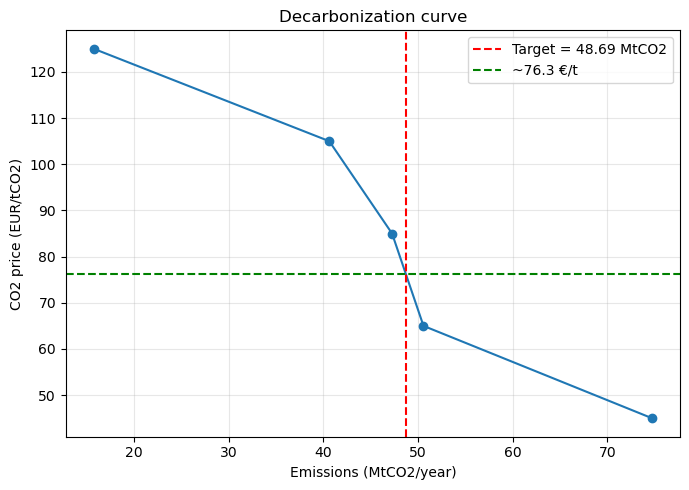

In [45]:
plt.figure(figsize=(7, 5))
plt.plot(df_results["emissions_MtCO2"], df_results["co2_price_eur_per_t"], marker="o")
plt.axvline(target_emissions / 1e6, color="red", linestyle="--", label=f"Target = {target_emissions/1e6:.2f} MtCO2")
plt.axhline(price_at_target, color="green", linestyle="--", label=f"~{price_at_target:.1f} €/t")
plt.xlabel("Emissions (MtCO2/year)")
plt.ylabel("CO2 price (EUR/tCO2)")
plt.title("Decarbonization curve")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("output/co2_sweep_curve.png", dpi=200, bbox_inches="tight")
plt.show()

In [46]:
# 9) Useful summary tables
summary = pd.DataFrame({
    "metric": ["base_emissions_MtCO2", "target_fraction", "target_emissions_MtCO2", "approx_co2_price_EUR_per_t"],
    "value": [base_emissions / 1e6, target_fraction, target_emissions / 1e6, price_at_target],
})
summary.to_csv("output/co2_summary.csv", index=False)
print(summary)


                       metric      value
0        base_emissions_MtCO2  74.914286
1             target_fraction   0.650000
2      target_emissions_MtCO2  48.694286
3  approx_co2_price_EUR_per_t  76.335600
